In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import os
import contextily as ctx
from glob import glob

from pathlib import Path


# Read XYZ file directly. You can get it at: https://www.swisstopo.admin.ch/en/height-model-swissaltiregio
root_dir = "data/heights"


dfs = []


for csv_path in glob(f"{root_dir}/**/*.xyz/*.xyz", recursive=True):
    # print(f"Reading {csv_path}...")
    df = pd.read_csv(csv_path, sep=' ', header=1, names=['X', 'Y', 'Z'])
    df = df.sample(n=10000, random_state=42)
    dfs.append(df)
    # do something with csv_path


big_df = pd.concat(dfs, ignore_index=True)



print(big_df.head(10))

# Create GeoDataFrame from the points
geometry = [Point(xy) for xy in zip(big_df['X'], big_df['Y'])]
gdf = gpd.GeoDataFrame(big_df, geometry=geometry, crs='EPSG:2056')  # Coordinate system: LV95 (EPSG 2056)

print(f"Loaded {len(gdf)} points")
print(gdf.head())
print(f"Z range: {big_df['Z'].min():.2f} to {big_df['Z'].max():.2f} meters")

           X        Y       Z
0  2677315.0  1244125  525.61
1  2684555.0  1253205  429.69
2  2676315.0  1248325  577.72
3  2683925.0  1248995  517.29
4  2679005.0  1253445  441.23
5  2675505.0  1252645  440.65
6  2684505.0  1247065  437.67
7  2675575.0  1246675  496.32
8  2678345.0  1253485  443.36
9  2678535.0  1244045  546.42
Loaded 310000 points
           X        Y       Z                 geometry
0  2677315.0  1244125  525.61  POINT (2677315 1244125)
1  2684555.0  1253205  429.69  POINT (2684555 1253205)
2  2676315.0  1248325  577.72  POINT (2676315 1248325)
3  2683925.0  1248995  517.29  POINT (2683925 1248995)
4  2679005.0  1253445  441.23  POINT (2679005 1253445)
Z range: 319.87 to 1563.44 meters


In [2]:
# reduce number of points for plotting to a random sample of 10000
gdf = gdf.sample(n=100000, random_state=42)

Added color based on elevation
Plotted points with basemap


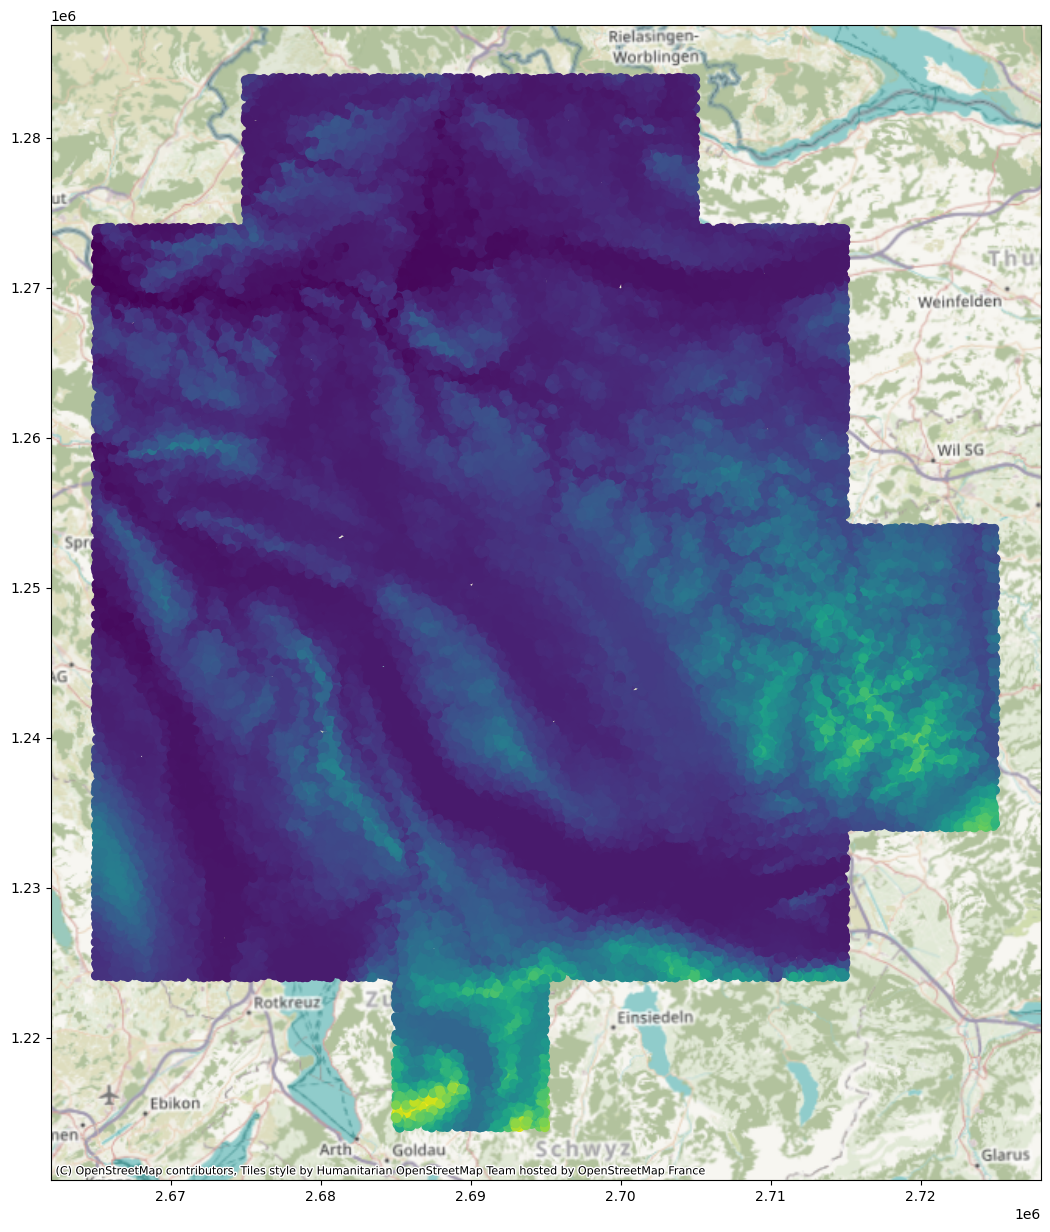

In [3]:

# gdf['color'] = gdf['purpose'].apply(lambda x: 'grey' if x == 'outside' else 'blue')


# Assign a color proportional to elevation
gdf['color'] = gdf['Z']
# .apply(lambda z: (z - gdf['Z'].min()) / (gdf['Z'].max() - gdf['Z'].min()))

print("Added color based on elevation")

ax = gdf.plot(
    figsize=(15,15),
    legend=True,
    c=gdf['color']
)

ctx.add_basemap(ax=ax, crs=gdf.crs)

print("Plotted points with basemap")

gdf = gdf.drop(columns=['color'], axis=1)